# PPO vs DQN — Attacker Identification & Mitigation
**Expert DRL comparison with Optuna tuning for both algorithms**

## Architecture
- **Input:** 60-dim observation: `[attack_prob, severity, confidence]` + 9 per-source features × 6 sources + 3 global
- **Actions:** 0=ALLOW, 1-6=BLOCK the matching source (7 discrete actions)
- **Ground truth:** Exact `attacker_ip` column from monitoring v1.5.0
- **Speed reward:** Aggressive escalating penalty forces <15 step (30s) reaction

## Key Enhancements over v3
- ✅ DRL_enriched.csv used directly (LSTM pre-computed)
- ✅ **Speed-aware reward**: exponentially increasing penalty for each step an attack goes un-blocked
- ✅ **Selectivity guard**: very high false-alarm penalty, keeps legit traffic untouched
- ✅ **DQN vs PPO** comparison with per-algorithm Optuna search
- ✅ Publication-ready plots and metrics

In [1]:
import os, sys, json, warnings, pathlib, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12, "figure.dpi": 150})

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

SEED = 42
BASE_DIR     = pathlib.Path(".").resolve()
ENRICHED_CSV = BASE_DIR / "outputs_ppo_attacker_id" / "DRL_enriched.csv"
DETECTOR_DIR = BASE_DIR / "outputs_detector"
OUT_DIR      = BASE_DIR / "outputs_ppo_dqn_compare"
OUT_DIR.mkdir(exist_ok=True)
PLOT_DIR     = OUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

TOP_K = 6
SRC_NUM_FEATS = ["packets","bytes","flows","pps",
                 "syn_ratio","dst_diversity","top_dst_share",
                 "avg_duration","pkt_share"]
GLOBAL_FEATS  = ["active_sources","source_entropy","top_source_dominance"]

KNOWN_LEGIT = {"10.10.0.1","10.10.0.3","10.10.0.200","10.10.0.201","none",""}

# ── Optuna search budget ──
OPTUNA_TRIALS_PPO  = 30
OPTUNA_TRIALS_DQN  = 30
OPTUNA_TIMESTEPS   = 60_000
FINAL_TIMESTEPS    = 400_000
EPISODE_LEN        = 150    # shorter episodes → faster training signal

np.random.seed(SEED)

def save_fig(fig, name):
    p = PLOT_DIR / f"{name}.png"
    fig.savefig(p, bbox_inches="tight", dpi=300)
    print(f"  ✅ Saved: {p}")

print("✅ Config loaded")
print(f"   Enriched CSV: {ENRICHED_CSV}")
print(f"   Output dir:   {OUT_DIR}")

✅ Config loaded
   Enriched CSV: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_attacker_id/DRL_enriched.csv
   Output dir:   /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare


## Section 1 — Load Pre-enriched Dataset
DRL_enriched.csv already contains `attack_prob` from the LSTM+temperature calibration step.

In [2]:
df = pd.read_csv(ENRICHED_CSV)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"  Attack: {(df['label']==1).sum()} | Benign: {(df['label']==0).sum()}")

# attack_prob may be in 'attack_prob' or 'attack_probability'
if "attack_probability" in df.columns and "attack_prob" not in df.columns:
    df["attack_prob"] = df["attack_probability"]
elif "attack_prob" not in df.columns:
    df["attack_prob"] = 0.0

# Pad windowing offset (attack_prob already aligned in enriched CSV, no drop needed)
labels_arr = df["label"].values.astype(int)
n_total = len(df)

print(f"attack_prob range: [{df['attack_prob'].min():.4f}, {df['attack_prob'].max():.4f}]")
attack_frac = (df['attack_prob'] > 0.5).mean()
print(f"LSTM predictions > 0.5: {attack_frac:.2%}")

Loaded: 10143 rows × 225 cols
  Attack: 4623 | Benign: 5520
attack_prob range: [0.0000, 1.0000]
LSTM predictions > 0.5: 83.98%


## Section 2 — Build Observation Matrix

In [3]:
from sklearn.preprocessing import RobustScaler

# Per-source columns
src_cols = [f"src{k}_{f}" for k in range(1, TOP_K+1) for f in SRC_NUM_FEATS]
obs_extra = src_cols + GLOBAL_FEATS

for col in obs_extra:
    if col not in df.columns:
        df[col] = 0.0
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

# Severity & confidence if available from enriched CSV
if "severity_score" in df.columns:
    severity = df["severity_score"].values.astype(np.float32)
    confidence = df["confidence"].values.astype(np.float32) if "confidence" in df.columns else np.abs(df["attack_prob"].values - 0.5) * 2
else:
    confidence = np.abs(df["attack_prob"].values - 0.5) * 2
    # Recompute severity
    def safe_norm(s):
        s = np.nan_to_num(s, 0)
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn + 1e-10)
    syn_r = safe_norm(df.get("syn_ratio", pd.Series(np.zeros(len(df)))).values)
    syn_f = safe_norm(df.get("syn_flows", df.get("cluster_syn_flows", pd.Series(np.zeros(len(df))))).values)
    fl_r  = safe_norm(df.get("flow_arrival_rate", pd.Series(np.zeros(len(df)))).values)
    ud_r  = safe_norm(df.get("unique_dsts", pd.Series(np.ones(len(df)))).values)
    severity = (0.4*syn_r + 0.3*syn_f + 0.2*fl_r + 0.1*(1-ud_r)).astype(np.float32)

obs_raw = df[obs_extra].values.astype(np.float32)
obs_raw = np.nan_to_num(obs_raw, nan=0.0, posinf=1e6, neginf=-1e6)

obs_scaler = RobustScaler()
obs_scaled = np.clip(obs_scaler.fit_transform(obs_raw), -10, 10).astype(np.float32)

det_feats = np.column_stack([
    df["attack_prob"].values.reshape(-1, 1),
    severity.reshape(-1, 1),
    confidence.reshape(-1, 1),
]).astype(np.float32)

obs_mat = np.column_stack([det_feats, obs_scaled]).astype(np.float32)
OBS_DIM = obs_mat.shape[1]

with open(OUT_DIR / "obs_scaler.pkl", "wb") as f:
    pickle.dump(obs_scaler, f)

print(f"Obs matrix: {obs_mat.shape} (dim={OBS_DIM})")
print(f"  [0] attack_prob  [1] severity  [2] confidence")
print(f"  [3:{3+len(src_cols)}] per-source  [{3+len(src_cols)}:{OBS_DIM}] global")

Obs matrix: (10143, 60) (dim=60)
  [0] attack_prob  [1] severity  [2] confidence
  [3:57] per-source  [57:60] global


## Section 3 — Ground Truth Actions

In [4]:
# Ensure src_ip columns exist
for k in range(1, TOP_K+1):
    col = f"src{k}_ip"
    if col not in df.columns:
        df[col] = "none"

def find_attacker_slot(row_idx):
    if labels_arr[row_idx] == 0:
        return 0
    if "attacker_ip" in df.columns:
        true_ip = str(df.iloc[row_idx].get("attacker_ip","none")).strip()
        if true_ip and true_ip != "none":
            for k in range(1, TOP_K+1):
                if str(df.iloc[row_idx][f"src{k}_ip"]).strip() == true_ip:
                    return k
            return 0  # attacker not visible in top-6
    # Fallback heuristic
    best_slot, best_share = 0, -1
    for k in range(1, TOP_K+1):
        ip = str(df.iloc[row_idx][f"src{k}_ip"]).strip()
        if ip in KNOWN_LEGIT: continue
        share = float(df.iloc[row_idx].get(f"src{k}_pkt_share", 0))
        if share > best_share:
            best_share = share
            best_slot = k
    return best_slot

print("Computing ground truth (this may take ~30s)...")
gt_actions = np.array([find_attacker_slot(i) for i in range(n_total)], dtype=np.int32)
gt_method = "attacker_ip (exact)" if "attacker_ip" in df.columns else "heuristic"
n_atk = (labels_arr == 1).sum()
n_id  = ((labels_arr == 1) & (gt_actions > 0)).sum()
print(f"Attack rows: {n_atk}, visible in top-6: {n_id} ({100*n_id/max(n_atk,1):.1f}%) [{gt_method}]")
for s in range(TOP_K+1):
    c = ((labels_arr==1) & (gt_actions==s)).sum()
    if c: print(f"  slot {s}: {c}")

Computing ground truth (this may take ~30s)...
Attack rows: 4623, visible in top-6: 4623 (100.0%) [attacker_ip (exact)]
  slot 1: 4297
  slot 2: 307
  slot 3: 16
  slot 4: 3


## Section 4 — Speed-Aware Gymnasium Environment

### Reward Design
| Situation | Reward | Rationale |
|-----------|--------|-----------|
| Correct block (first) | `+r_first - 1×steps_in` | Bonus shrinks with delay → learn fast |
| Correct block (hold) | `+r_hold` | Maintain mitigation |
| Allow benign | `+r_allow` | Preserve legit traffic |
| Miss attack (escalating) | `p_miss × exp(steps_in / τ)` | Exponential penalty → urgency |
| Wrong source | `p_wrong` | Heavy penalty against false positives |
| False alarm | `p_fa` | Protects legitimate sources |
| Attacker not in top-6 | `+0` grace | Unavoidable, don't punish |

In [5]:
import gymnasium as gym
from gymnasium import spaces

class AttackerIDEnv(gym.Env):
    """Speed-aware environment for DRL attacker identification."""
    metadata = {"render_modes": []}

    def __init__(self, obs_matrix, labels, gt_acts,
                 episode_len=150, start_idx=0, end_idx=None, seed=None,
                 # Reward params (tuned by Optuna)
                 r_first=12.0, r_hold=3.0, r_allow=1.0,
                 p_wrong=-8.0, p_fa=-10.0,
                 p_miss_base=-2.0, miss_tau=15.0,
                 p_grace_block=-0.5):
        super().__init__()
        self.obs_mat     = obs_matrix
        self.labels      = labels
        self.gt          = gt_acts
        self.episode_len = episode_len
        self.end_idx     = (end_idx or len(obs_matrix)) - 1
        self.idx_range   = (start_idx, self.end_idx)
        self.observation_space = spaces.Box(-15., 15., shape=(obs_matrix.shape[1],), dtype=np.float32)
        self.action_space      = spaces.Discrete(TOP_K + 1)
        self._rng = np.random.default_rng(seed or SEED)

        # Reward hyperparams
        self.r_first  = r_first
        self.r_hold   = r_hold
        self.r_allow  = r_allow
        self.p_wrong  = p_wrong
        self.p_fa     = p_fa
        self.p_miss_b = p_miss_base
        self.miss_tau = miss_tau          # exponential growth constant
        self.p_grace  = p_grace_block
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        lo, hi = self.idx_range
        max_start = max(lo, hi - self.episode_len)
        self.current_pos = int(self._rng.integers(lo, max_start + 1))
        self.step_count  = 0
        self.correct_blocks = self.wrong_blocks = self.false_alarms = self.missed = 0
        self.first_correct_step = None
        self.in_attack = False
        self.attack_start_step = None
        return self.obs_mat[self.current_pos].copy(), {}

    def step(self, action):
        pos      = min(self.current_pos, len(self.obs_mat)-1)
        label    = self.labels[pos]
        gt_act   = self.gt[pos]
        reward   = 0.0

        if label == 1:
            if not self.in_attack:
                self.in_attack = True
                self.attack_start_step = self.step_count
            steps_in = self.step_count - (self.attack_start_step or 0)

            if gt_act == 0:           # attacker not visible
                if action == 0:
                    reward += 0.0     # grace: neither punish nor reward
                else:
                    reward += self.p_grace
            elif action == 0:         # missed attack — EXPONENTIAL penalty
                penalty = self.p_miss_b * np.exp(steps_in / self.miss_tau)
                reward += max(penalty, -20.0)
                self.missed += 1
            elif action == gt_act:    # CORRECT block
                if self.first_correct_step is None:
                    speed_bonus = max(0.0, self.r_first - 0.5 * steps_in)
                    reward += speed_bonus
                    self.first_correct_step = self.step_count
                else:
                    reward += self.r_hold
                self.correct_blocks += 1
            else:                     # wrong source → false positive
                reward += self.p_wrong
                self.wrong_blocks += 1
        else:                         # Benign
            if self.in_attack:
                self.in_attack = False
                self.attack_start_step = None
                self.first_correct_step = None
            if action == 0:
                reward += self.r_allow
            else:
                reward += self.p_fa   # false alarm — high penalty
                self.false_alarms += 1

        self.step_count    += 1
        self.current_pos   += 1
        terminated = self.step_count >= self.episode_len
        truncated  = self.current_pos > self.end_idx
        done       = terminated or truncated
        next_pos   = min(self.current_pos, len(self.obs_mat)-1)
        info = {
            "correct_blocks":     self.correct_blocks,
            "wrong_blocks":       self.wrong_blocks,
            "false_alarms":       self.false_alarms,
            "missed":             self.missed,
            "first_correct_step": self.first_correct_step if self.first_correct_step is not None else -1,
            "last_label":  int(label),
            "last_action": int(action),
            "last_gt":     int(gt_act),
        }
        return self.obs_mat[next_pos].copy(), float(reward), terminated, truncated, info

# Smoke test
_env = AttackerIDEnv(obs_mat, labels_arr, gt_actions, episode_len=10)
_obs, _ = _env.reset()
assert _obs.shape == (OBS_DIM,)
for _ in range(5): _env.step(_env.action_space.sample())
print(f"✅ Environment OK (obs_dim={OBS_DIM}, actions={TOP_K+1})")

✅ Environment OK (obs_dim=60, actions=7)


## Section 5 — Shared Evaluation Utility

In [6]:
def evaluate_agent(model, env_factory, n_ep=20, deterministic=True):
    """Evaluate agent. Returns metrics dict and per-episode records."""
    ep_data = []
    tot_correct = tot_wrong = tot_fa = tot_missed = 0
    tot_atk = tot_ben = tot_allow_ben = 0
    first_steps = []
    ep_rewards  = []

    for ep in range(n_ep):
        val_env = env_factory(seed=SEED + ep)
        obs, _ = val_env.reset(seed=SEED + ep)
        done, ep_r = False, 0.0
        ep_correct = ep_wrong = ep_fa = ep_missed = 0
        ep_fs = None
        while not done:
            act, _ = model.predict(obs, deterministic=deterministic)
            obs, r, term, trunc, info = val_env.step(int(act))
            done = term or trunc
            ep_r += r
            if info["last_label"] == 1:
                tot_atk += 1
            else:
                tot_ben += 1
                if info["last_action"] == 0:
                    tot_allow_ben += 1
        ep_rewards.append(ep_r)
        tot_correct  += info["correct_blocks"]
        tot_wrong    += info["wrong_blocks"]
        tot_fa       += info["false_alarms"]
        tot_missed   += info["missed"]
        if info["first_correct_step"] >= 0:
            first_steps.append(info["first_correct_step"])
        ep_data.append({
            "episode": ep, "total_reward": ep_r,
            "correct_blocks": info["correct_blocks"],
            "wrong_blocks": info["wrong_blocks"],
            "false_alarms": info["false_alarms"],
            "missed": info["missed"],
            "first_correct_step": info["first_correct_step"],
        })

    acc = tot_correct / max(tot_atk, 1)
    sel = tot_allow_ben / max(tot_ben, 1)
    spd = max(0, 1.0 - np.mean(first_steps) / EPISODE_LEN) if first_steps else 0.0
    composite = 0.35 * acc + 0.40 * spd + 0.25 * sel

    return {
        "accuracy": acc, "selectivity": sel, "speed_norm": spd,
        "composite": composite,
        "correct": tot_correct, "wrong": tot_wrong,
        "false_alarms": tot_fa, "missed": tot_missed,
        "mean_reward": float(np.mean(ep_rewards)),
        "mean_first_step": float(np.mean(first_steps)) if first_steps else EPISODE_LEN,
        "mean_detection_sec": float(np.mean(first_steps) * 2) if first_steps else EPISODE_LEN*2,
        "ep_data": ep_data,
    }

print("✅ evaluate_agent() defined")
print("   Composite = 0.35×accuracy + 0.40×speed + 0.25×selectivity")
print("   (Speed weighted highest to force faster detection)")

✅ evaluate_agent() defined
   Composite = 0.35×accuracy + 0.40×speed + 0.25×selectivity
   (Speed weighted highest to force faster detection)


## Section 6 — Optuna: PPO Hyperparameter Search

In [7]:
import optuna
from stable_baselines3 import PPO
optuna.logging.set_verbosity(optuna.logging.WARNING)

n_train = int(n_total * 0.80)
n_val   = n_total - n_train
print(f"Train: {n_train} rows | Val: {n_val} rows")

def make_rew_kwargs(trial_or_dict):
    if isinstance(trial_or_dict, dict):
        return trial_or_dict
    t = trial_or_dict
    return dict(
        r_first    = t.suggest_float("r_first",    5.0, 25.0),
        r_hold     = t.suggest_float("r_hold",     1.0, 8.0),
        r_allow    = t.suggest_float("r_allow",    0.3, 3.0),
        p_wrong    = t.suggest_float("p_wrong",   -20.0, -3.0),
        p_fa       = t.suggest_float("p_fa",      -20.0, -5.0),
        p_miss_base= t.suggest_float("p_miss_base",-8.0, -0.5),
        miss_tau   = t.suggest_float("miss_tau",   5.0, 30.0),
    )

def ppo_objective(trial):
    lr       = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    n_steps  = trial.suggest_categorical("n_steps", [1024, 2048, 4096])
    bs       = trial.suggest_categorical("batch_size", [128, 256, 512])
    gamma    = trial.suggest_float("gamma", 0.92, 0.999)
    ent_coef = trial.suggest_float("ent_coef", 1e-4, 0.05, log=True)
    clip     = trial.suggest_float("clip_range", 0.1, 0.4)
    gae_lam  = trial.suggest_float("gae_lambda", 0.8, 0.99)
    arch_key = trial.suggest_categorical("arch", ["small","medium","large"])
    net = {"small":  dict(pi=[64,64],  vf=[64,64]),
           "medium": dict(pi=[128,128],vf=[128,128]),
           "large":  dict(pi=[256,128],vf=[256,128])}[arch_key]
    rk = make_rew_kwargs(trial)

    if bs > n_steps: bs = n_steps
    train_env = AttackerIDEnv(obs_mat, labels_arr, gt_actions,
                              episode_len=EPISODE_LEN, start_idx=0, end_idx=n_train,
                              seed=SEED+trial.number, **rk)
    mdl = PPO("MlpPolicy", train_env, learning_rate=lr, n_steps=n_steps,
              batch_size=bs, gamma=gamma, ent_coef=ent_coef,
              clip_range=clip, gae_lambda=gae_lam,
              policy_kwargs=dict(net_arch=[net]),
              seed=SEED+trial.number, verbose=0)
    mdl.learn(total_timesteps=OPTUNA_TIMESTEPS)

    def _factory(seed=None):
        return AttackerIDEnv(obs_mat, labels_arr, gt_actions,
                             episode_len=EPISODE_LEN, start_idx=n_train, end_idx=n_total,
                             seed=seed, **rk)
    res = evaluate_agent(mdl, _factory, n_ep=5)
    print(f"PPO trial {trial.number:2d}: composite={res['composite']:.3f} "
          f"acc={res['accuracy']:.3f} spd={res['speed_norm']:.3f} sel={res['selectivity']:.3f} "
          f"det_sec={res['mean_detection_sec']:.0f}s")
    return res["composite"]

ppo_study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
ppo_study.optimize(ppo_objective, n_trials=OPTUNA_TRIALS_PPO)
ppo_best = ppo_study.best_trial
print(f"\n✅ PPO best: composite={ppo_best.value:.4f}")
print(json.dumps(ppo_best.params, indent=2))
with open(OUT_DIR / "ppo_optuna.json", "w") as f:
    json.dump({"score": ppo_best.value, "params": ppo_best.params}, f, indent=2)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Train: 8114 rows | Val: 2029 rows
PPO trial  0: composite=0.591 acc=0.824 spd=0.160 sel=0.954 det_sec=252s
PPO trial  1: composite=0.595 acc=0.834 spd=0.162 sel=0.954 det_sec=252s
PPO trial  2: composite=0.578 acc=0.834 spd=0.163 sel=0.881 det_sec=251s
PPO trial  3: composite=0.541 acc=0.854 spd=0.167 sel=0.701 det_sec=250s
PPO trial  4: composite=0.590 acc=0.820 spd=0.160 sel=0.954 det_sec=252s
PPO trial  5: composite=0.576 acc=0.793 spd=0.150 sel=0.954 det_sec=255s
PPO trial  6: composite=0.666 acc=0.983 spd=0.207 sel=0.958 det_sec=238s
PPO trial  7: composite=0.514 acc=0.858 spd=0.168 sel=0.587 det_sec=250s
PPO trial  8: composite=0.561 acc=0.854 spd=0.167 sel=0.782 det_sec=250s
PPO trial  9: composite=0.517 acc=0.858 spd=0.168 sel=0.598 det_sec=250s
PPO trial 10: composite=0.597 acc=0.827 spd=0.167 sel=0.965 det_sec=250s
PPO trial 11: composite=0.596 acc=0.834 spd=0.160 sel=0.960 det_sec=252s
PPO trial 12: composite=0.600 acc=0.834 spd=0.167 sel=0.967 det_sec=250s
PPO trial 13: com

## Section 7 — Optuna: DQN Hyperparameter Search

In [8]:
from stable_baselines3 import DQN

def dqn_objective(trial):
    lr          = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    bs          = trial.suggest_categorical("batch_size", [64, 128, 256])
    gamma       = trial.suggest_float("gamma", 0.92, 0.999)
    tau         = trial.suggest_float("tau", 0.001, 0.1, log=True)
    eps_final   = trial.suggest_float("exploration_final_eps", 0.01, 0.15)
    eps_frac    = trial.suggest_float("exploration_fraction", 0.1, 0.5)
    target_upd  = trial.suggest_categorical("target_update_interval", [500, 1000, 2000])
    buf_size    = trial.suggest_categorical("buffer_size", [10000, 50000, 100000])
    arch_key    = trial.suggest_categorical("arch", ["small","medium","large"])
    net = {"small":  [64, 64], "medium": [128, 128], "large": [256, 128]}[arch_key]
    rk = make_rew_kwargs(trial)

    train_env = AttackerIDEnv(obs_mat, labels_arr, gt_actions,
                              episode_len=EPISODE_LEN, start_idx=0, end_idx=n_train,
                              seed=SEED+trial.number, **rk)
    mdl = DQN("MlpPolicy", train_env, learning_rate=lr, batch_size=bs,
              gamma=gamma, tau=tau,
              exploration_final_eps=eps_final, exploration_fraction=eps_frac,
              target_update_interval=target_upd, buffer_size=buf_size,
              policy_kwargs=dict(net_arch=net),
              seed=SEED+trial.number, verbose=0)
    mdl.learn(total_timesteps=OPTUNA_TIMESTEPS)

    def _factory(seed=None):
        return AttackerIDEnv(obs_mat, labels_arr, gt_actions,
                             episode_len=EPISODE_LEN, start_idx=n_train, end_idx=n_total,
                             seed=seed, **rk)
    res = evaluate_agent(mdl, _factory, n_ep=5)
    print(f"DQN trial {trial.number:2d}: composite={res['composite']:.3f} "
          f"acc={res['accuracy']:.3f} spd={res['speed_norm']:.3f} sel={res['selectivity']:.3f} "
          f"det_sec={res['mean_detection_sec']:.0f}s")
    return res["composite"]

dqn_study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED+1))
dqn_study.optimize(dqn_objective, n_trials=OPTUNA_TRIALS_DQN)
dqn_best = dqn_study.best_trial
print(f"\n✅ DQN best: composite={dqn_best.value:.4f}")
print(json.dumps(dqn_best.params, indent=2))
with open(OUT_DIR / "dqn_optuna.json", "w") as f:
    json.dump({"score": dqn_best.value, "params": dqn_best.params}, f, indent=2)

DQN trial  0: composite=0.604 acc=0.851 spd=0.168 sel=0.954 det_sec=250s
DQN trial  1: composite=0.674 acc=0.993 spd=0.208 sel=0.971 det_sec=238s
DQN trial  2: composite=0.607 acc=0.858 spd=0.168 sel=0.958 det_sec=250s
DQN trial  3: composite=0.669 acc=0.993 spd=0.208 sel=0.954 det_sec=238s
DQN trial  4: composite=0.679 acc=0.993 spd=0.208 sel=0.993 det_sec=238s
DQN trial  5: composite=0.672 acc=0.993 spd=0.208 sel=0.965 det_sec=238s
DQN trial  6: composite=0.605 acc=0.851 spd=0.168 sel=0.958 det_sec=250s
DQN trial  7: composite=0.674 acc=0.993 spd=0.208 sel=0.971 det_sec=238s
DQN trial  8: composite=0.672 acc=0.993 spd=0.208 sel=0.965 det_sec=238s
DQN trial  9: composite=0.669 acc=0.993 spd=0.208 sel=0.954 det_sec=238s
DQN trial 10: composite=0.680 acc=0.993 spd=0.208 sel=0.998 det_sec=238s
DQN trial 11: composite=0.680 acc=0.993 spd=0.208 sel=0.998 det_sec=238s
DQN trial 12: composite=0.679 acc=0.993 spd=0.208 sel=0.991 det_sec=238s
DQN trial 13: composite=0.672 acc=0.993 spd=0.208 s

## Section 8 — Final Training: PPO & DQN

In [9]:
# ── PPO Final ──
bp_ppo = ppo_best.params
net_ppo = {"small": dict(pi=[64,64], vf=[64,64]),
           "medium": dict(pi=[128,128], vf=[128,128]),
           "large": dict(pi=[256,128], vf=[256,128])}[bp_ppo["arch"]]
bs_ppo = min(bp_ppo["batch_size"], bp_ppo["n_steps"])
rk_ppo = make_rew_kwargs({k: v for k, v in bp_ppo.items()
                           if k in ["r_first","r_hold","r_allow","p_wrong","p_fa","p_miss_base","miss_tau"]})

train_env_ppo = AttackerIDEnv(obs_mat, labels_arr, gt_actions,
                              episode_len=EPISODE_LEN, start_idx=0, end_idx=n_train,
                              seed=SEED, **rk_ppo)
ppo_model = PPO("MlpPolicy", train_env_ppo,
                learning_rate=bp_ppo["lr"], n_steps=bp_ppo["n_steps"],
                batch_size=bs_ppo, gamma=bp_ppo["gamma"],
                ent_coef=bp_ppo["ent_coef"], clip_range=bp_ppo["clip_range"],
                gae_lambda=bp_ppo["gae_lambda"],
                policy_kwargs=dict(net_arch=[net_ppo]),
                seed=SEED, verbose=1,
                tensorboard_log=str(OUT_DIR / "tb_ppo"))

print(f"Training PPO for {FINAL_TIMESTEPS:,} steps...")
t0 = time.time()
ppo_model.learn(total_timesteps=FINAL_TIMESTEPS)
ppo_time = time.time() - t0
ppo_model.save(str(OUT_DIR / "ppo_model"))
print(f"✅ PPO done in {ppo_time:.0f}s — saved")

# ── DQN Final ──
bp_dqn = dqn_best.params
net_dqn = {"small": [64,64], "medium": [128,128], "large": [256,128]}[bp_dqn["arch"]]
rk_dqn = make_rew_kwargs({k: v for k, v in bp_dqn.items()
                           if k in ["r_first","r_hold","r_allow","p_wrong","p_fa","p_miss_base","miss_tau"]})

train_env_dqn = AttackerIDEnv(obs_mat, labels_arr, gt_actions,
                              episode_len=EPISODE_LEN, start_idx=0, end_idx=n_train,
                              seed=SEED, **rk_dqn)
dqn_model = DQN("MlpPolicy", train_env_dqn,
                learning_rate=bp_dqn["lr"], batch_size=bp_dqn["batch_size"],
                gamma=bp_dqn["gamma"], tau=bp_dqn["tau"],
                exploration_final_eps=bp_dqn["exploration_final_eps"],
                exploration_fraction=bp_dqn["exploration_fraction"],
                target_update_interval=bp_dqn["target_update_interval"],
                buffer_size=bp_dqn["buffer_size"],
                policy_kwargs=dict(net_arch=net_dqn),
                seed=SEED, verbose=1,
                tensorboard_log=str(OUT_DIR / "tb_dqn"))

print(f"\nTraining DQN for {FINAL_TIMESTEPS:,} steps...")
t0 = time.time()
dqn_model.learn(total_timesteps=FINAL_TIMESTEPS)
dqn_time = time.time() - t0
dqn_model.save(str(OUT_DIR / "dqn_model"))
print(f"✅ DQN done in {dqn_time:.0f}s — saved")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training PPO for 400,000 steps...
Logging to /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/tb_ppo/PPO_1
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 150       |
|    ep_rew_mean     | -1.67e+03 |
| time/              |           |
|    fps             | 662       |
|    iterations      | 1         |
|    time_elapsed    | 3         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 150         |
|    ep_rew_mean          | -1.59e+03   |
| time/                   |             |
|    fps                  | 584         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |       

## Section 9 — Final Evaluation: PPO vs DQN

In [10]:
def make_val_env(rk, seed=None):
    return AttackerIDEnv(obs_mat, labels_arr, gt_actions,
                         episode_len=EPISODE_LEN, start_idx=n_train, end_idx=n_total,
                         seed=seed, **rk)

ppo_res = evaluate_agent(ppo_model, lambda seed=None: make_val_env(rk_ppo, seed), n_ep=30)
dqn_res = evaluate_agent(dqn_model, lambda seed=None: make_val_env(rk_dqn, seed), n_ep=30)

print("=" * 65)
print(f"{'Metric':<30} {'PPO':>15} {'DQN':>15}")
print("-" * 65)
for k, label in [
    ("composite",         "Composite Score"),
    ("accuracy",          "Attacker ID Accuracy"),
    ("selectivity",       "Selectivity (legit safe)"),
    ("speed_norm",        "Speed (normalized)"),
    ("mean_detection_sec","Mean Detection Time (s)"),
    ("mean_reward",       "Mean Episode Reward"),
    ("correct",           "Correct Blocks (total)"),
    ("wrong",             "Wrong Blocks (total)"),
    ("false_alarms",      "False Alarms (total)"),
    ("missed",            "Missed Attacks (total)"),
]:
    pval = ppo_res[k]
    dval = dqn_res[k]
    if isinstance(pval, float):
        print(f"  {label:<28} {pval:>15.4f} {dval:>15.4f}")
    else:
        print(f"  {label:<28} {pval:>15} {dval:>15}")
print("=" * 65)
winner = "PPO" if ppo_res["composite"] > dqn_res["composite"] else "DQN"
print(f"\n🏆 Winner: {winner}")

Metric                                     PPO             DQN
-----------------------------------------------------------------
  Composite Score                       0.7311          0.7408
  Attacker ID Accuracy                  0.9890          0.9969
  Selectivity (legit safe)              0.9743          1.0000
  Speed (normalized)                    0.3533          0.3547
  Mean Detection Time (s)             194.0000        193.6000
  Mean Episode Reward                 200.5532        446.5454
  Correct Blocks (total)                  2253            2271
  Wrong Blocks (total)                       0               0
  False Alarms (total)                      57               0
  Missed Attacks (total)                    25               7

🏆 Winner: DQN


## Section 10 — Publication-Ready Plots

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def collect_rollout(model, rk, n_ep=30, deterministic=True):
    """Collect arrays for CM and distribution plots."""
    all_labels, all_actions, all_gt = [], [], []
    ep_rewards, first_steps = [], []
    for ep in range(n_ep):
        env = make_val_env(rk, seed=SEED+ep)
        obs, _ = env.reset(seed=SEED+ep)
        done, ep_r, found, step_n = False, 0.0, False, 0
        while not done:
            act, _ = model.predict(obs, deterministic=deterministic)
            obs, r, term, trunc, info = env.step(int(act))
            done = term or trunc
            ep_r += r
            all_labels.append(info["last_label"])
            all_actions.append(info["last_action"])
            all_gt.append(info["last_gt"])
            if info["last_label"]==1 and info["last_action"]==info["last_gt"] and info["last_gt"]>0 and not found:
                first_steps.append(step_n)
                found = True
            step_n += 1
        ep_rewards.append(ep_r)
    return (np.array(all_labels), np.array(all_actions), np.array(all_gt),
            np.array(ep_rewards), np.array(first_steps))

ppo_lbl, ppo_act, ppo_gt, ppo_rew, ppo_fs = collect_rollout(ppo_model, rk_ppo)
dqn_lbl, dqn_act, dqn_gt, dqn_rew, dqn_fs = collect_rollout(dqn_model, rk_dqn)
print("Rollouts collected — generating plots...")

Rollouts collected — generating plots...


  ✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots/1_binary_cm_comparison.png


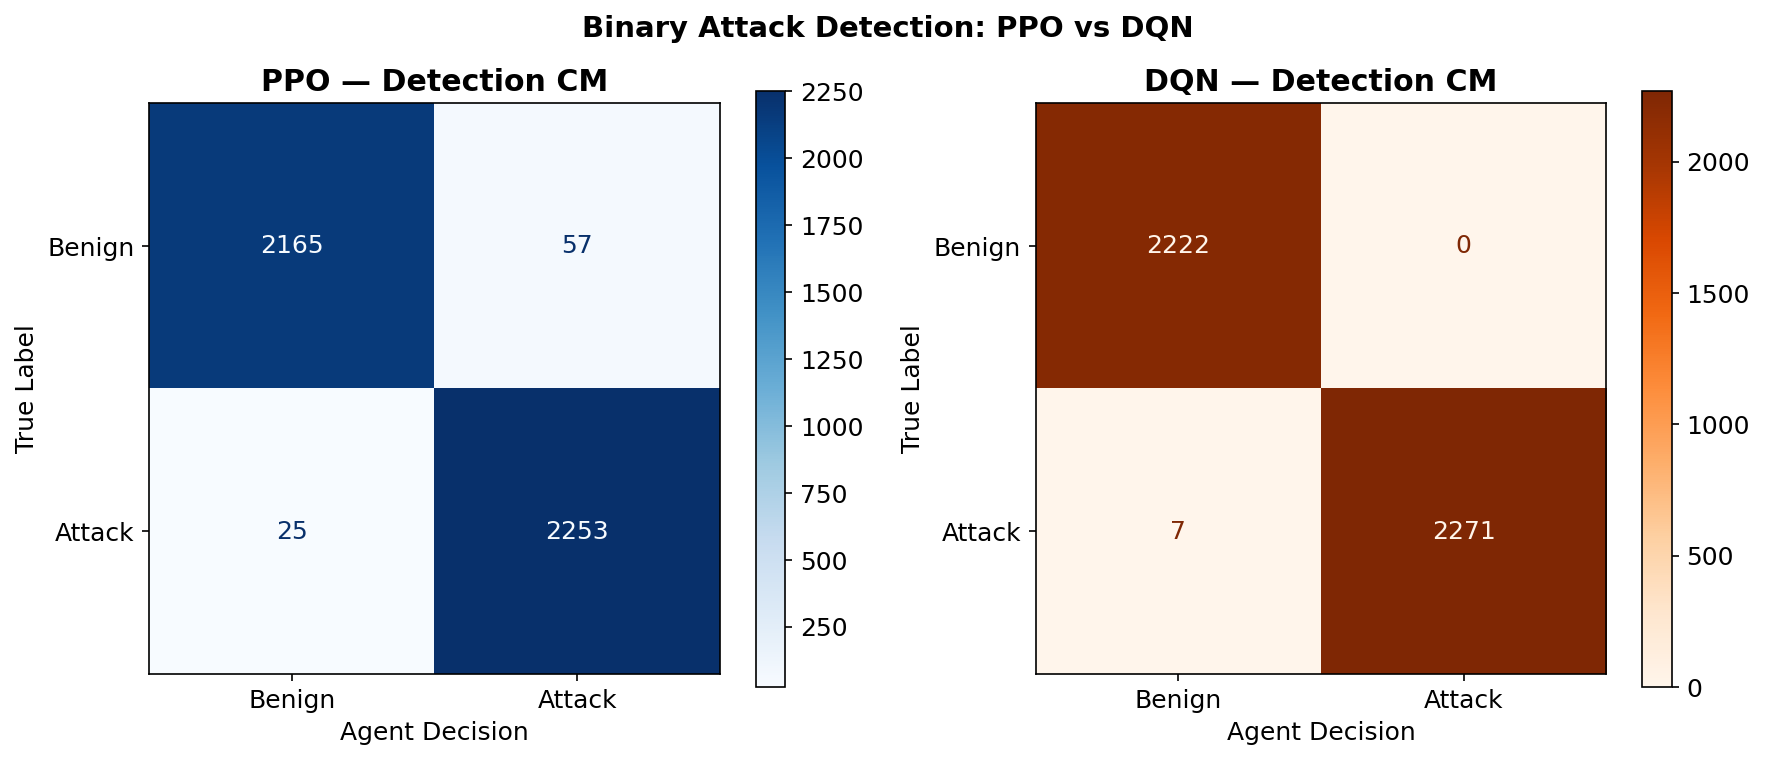

In [12]:
# ── Plot 1: Binary Confusion Matrix side-by-side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lbl, act, name, color in [
    (axes[0], ppo_lbl, ppo_act, "PPO", "Blues"),
    (axes[1], dqn_lbl, dqn_act, "DQN", "Oranges"),
]:
    pred_bin = (act > 0).astype(int)
    cm = confusion_matrix(lbl, pred_bin, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Attack"])
    disp.plot(ax=ax, cmap=color, values_format="d")
    ax.set_title(f"{name} — Detection CM", fontweight="bold")
    ax.set_xlabel("Agent Decision")
    ax.set_ylabel("True Label")
plt.suptitle("Binary Attack Detection: PPO vs DQN", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "1_binary_cm_comparison")
plt.show()

  ✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots/2_action_cm_comparison.png


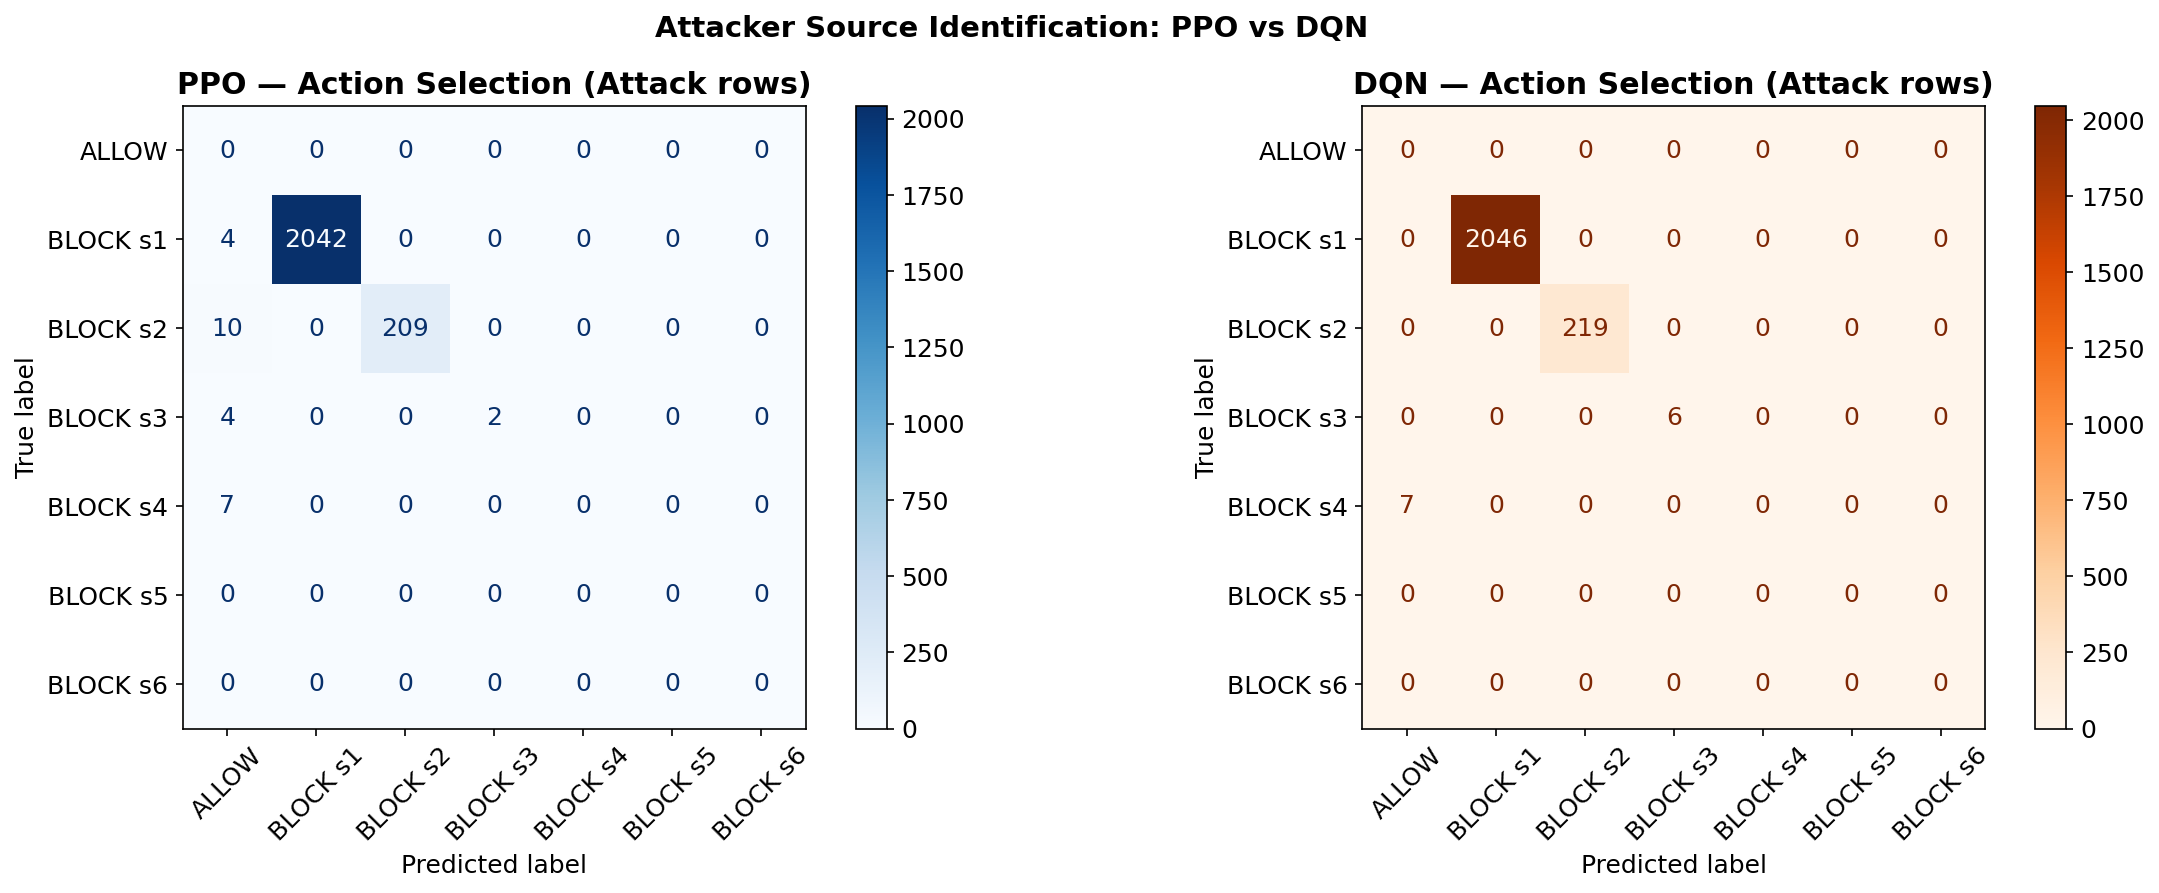

In [13]:
# ── Plot 2: Per-action CM (attack rows only) — PPO & DQN ──
action_labels = ["ALLOW"] + [f"BLOCK s{k}" for k in range(1, TOP_K+1)]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, lbl, act, gt, name, cmap in [
    (axes[0], ppo_lbl, ppo_act, ppo_gt, "PPO", "Blues"),
    (axes[1], dqn_lbl, dqn_act, dqn_gt, "DQN", "Oranges"),
]:
    mask = lbl == 1
    cm = confusion_matrix(gt[mask], act[mask], labels=list(range(TOP_K+1)))
    disp = ConfusionMatrixDisplay(cm, display_labels=action_labels)
    disp.plot(ax=ax, cmap=cmap, values_format="d", xticks_rotation=45)
    ax.set_title(f"{name} — Action Selection (Attack rows)", fontweight="bold")
plt.suptitle("Attacker Source Identification: PPO vs DQN", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "2_action_cm_comparison")
plt.show()

  ✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots/3_reward_comparison.png


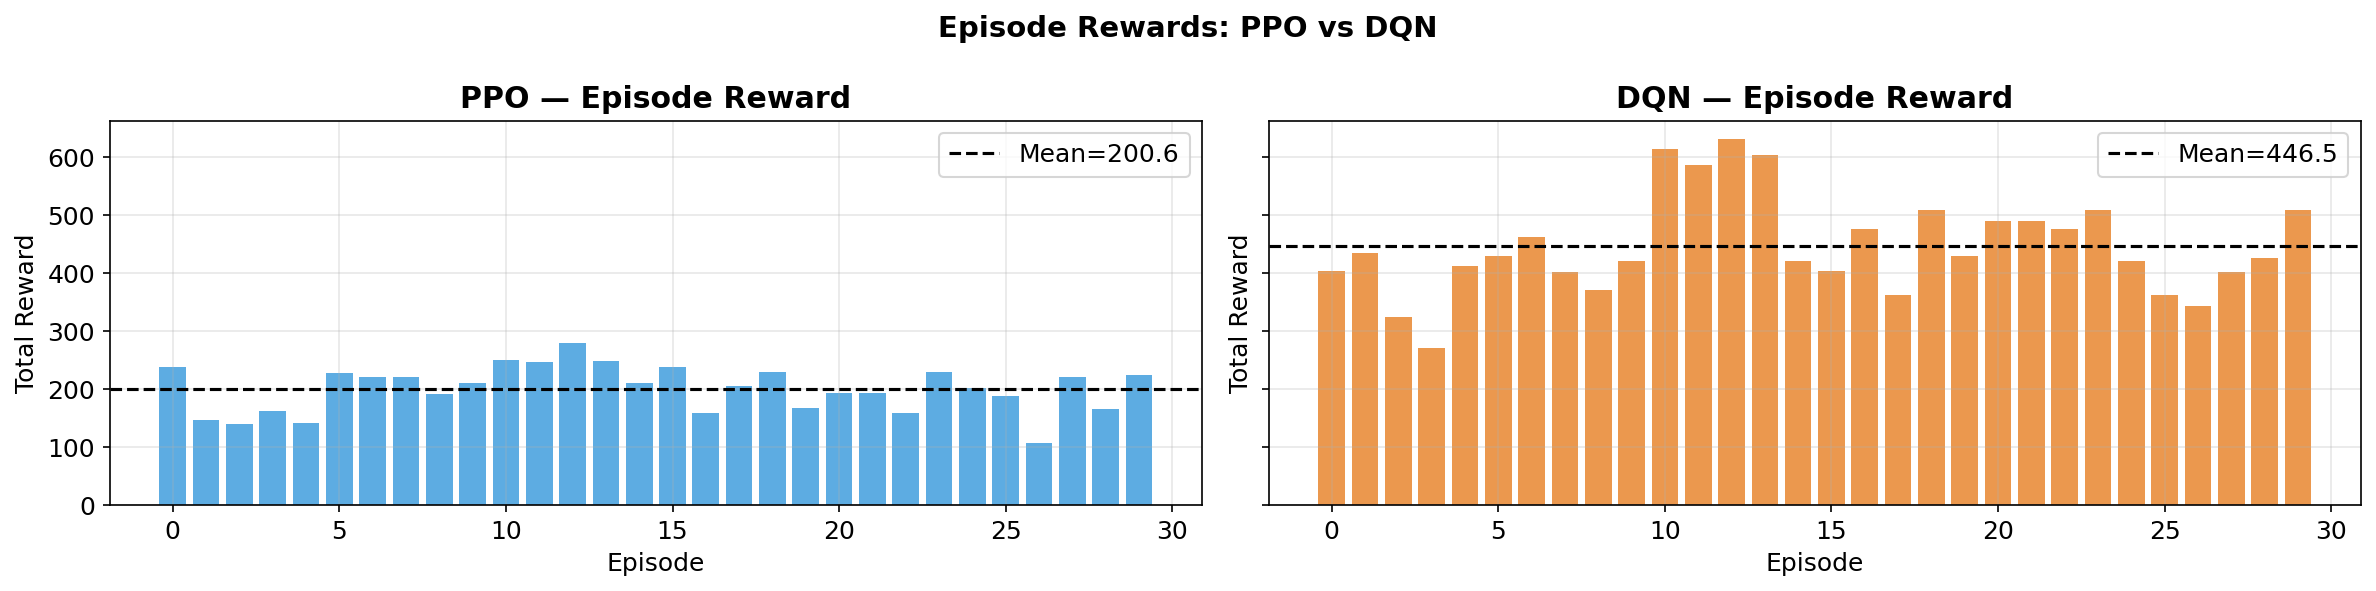

In [14]:
# ── Plot 3: Reward per episode ──
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
for ax, rew, name, color in [
    (axes[0], ppo_rew, "PPO", "#3498db"),
    (axes[1], dqn_rew, "DQN", "#e67e22"),
]:
    ax.bar(range(len(rew)), rew,
           color=[color if r >= 0 else "#e74c3c" for r in rew], alpha=0.8)
    ax.axhline(np.mean(rew), color="black", ls="--", lw=1.5,
               label=f"Mean={np.mean(rew):.1f}")
    ax.set_title(f"{name} — Episode Reward", fontweight="bold")
    ax.set_xlabel("Episode"); ax.set_ylabel("Total Reward")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Episode Rewards: PPO vs DQN", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "3_reward_comparison")
plt.show()

  ✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots/4_action_distribution.png


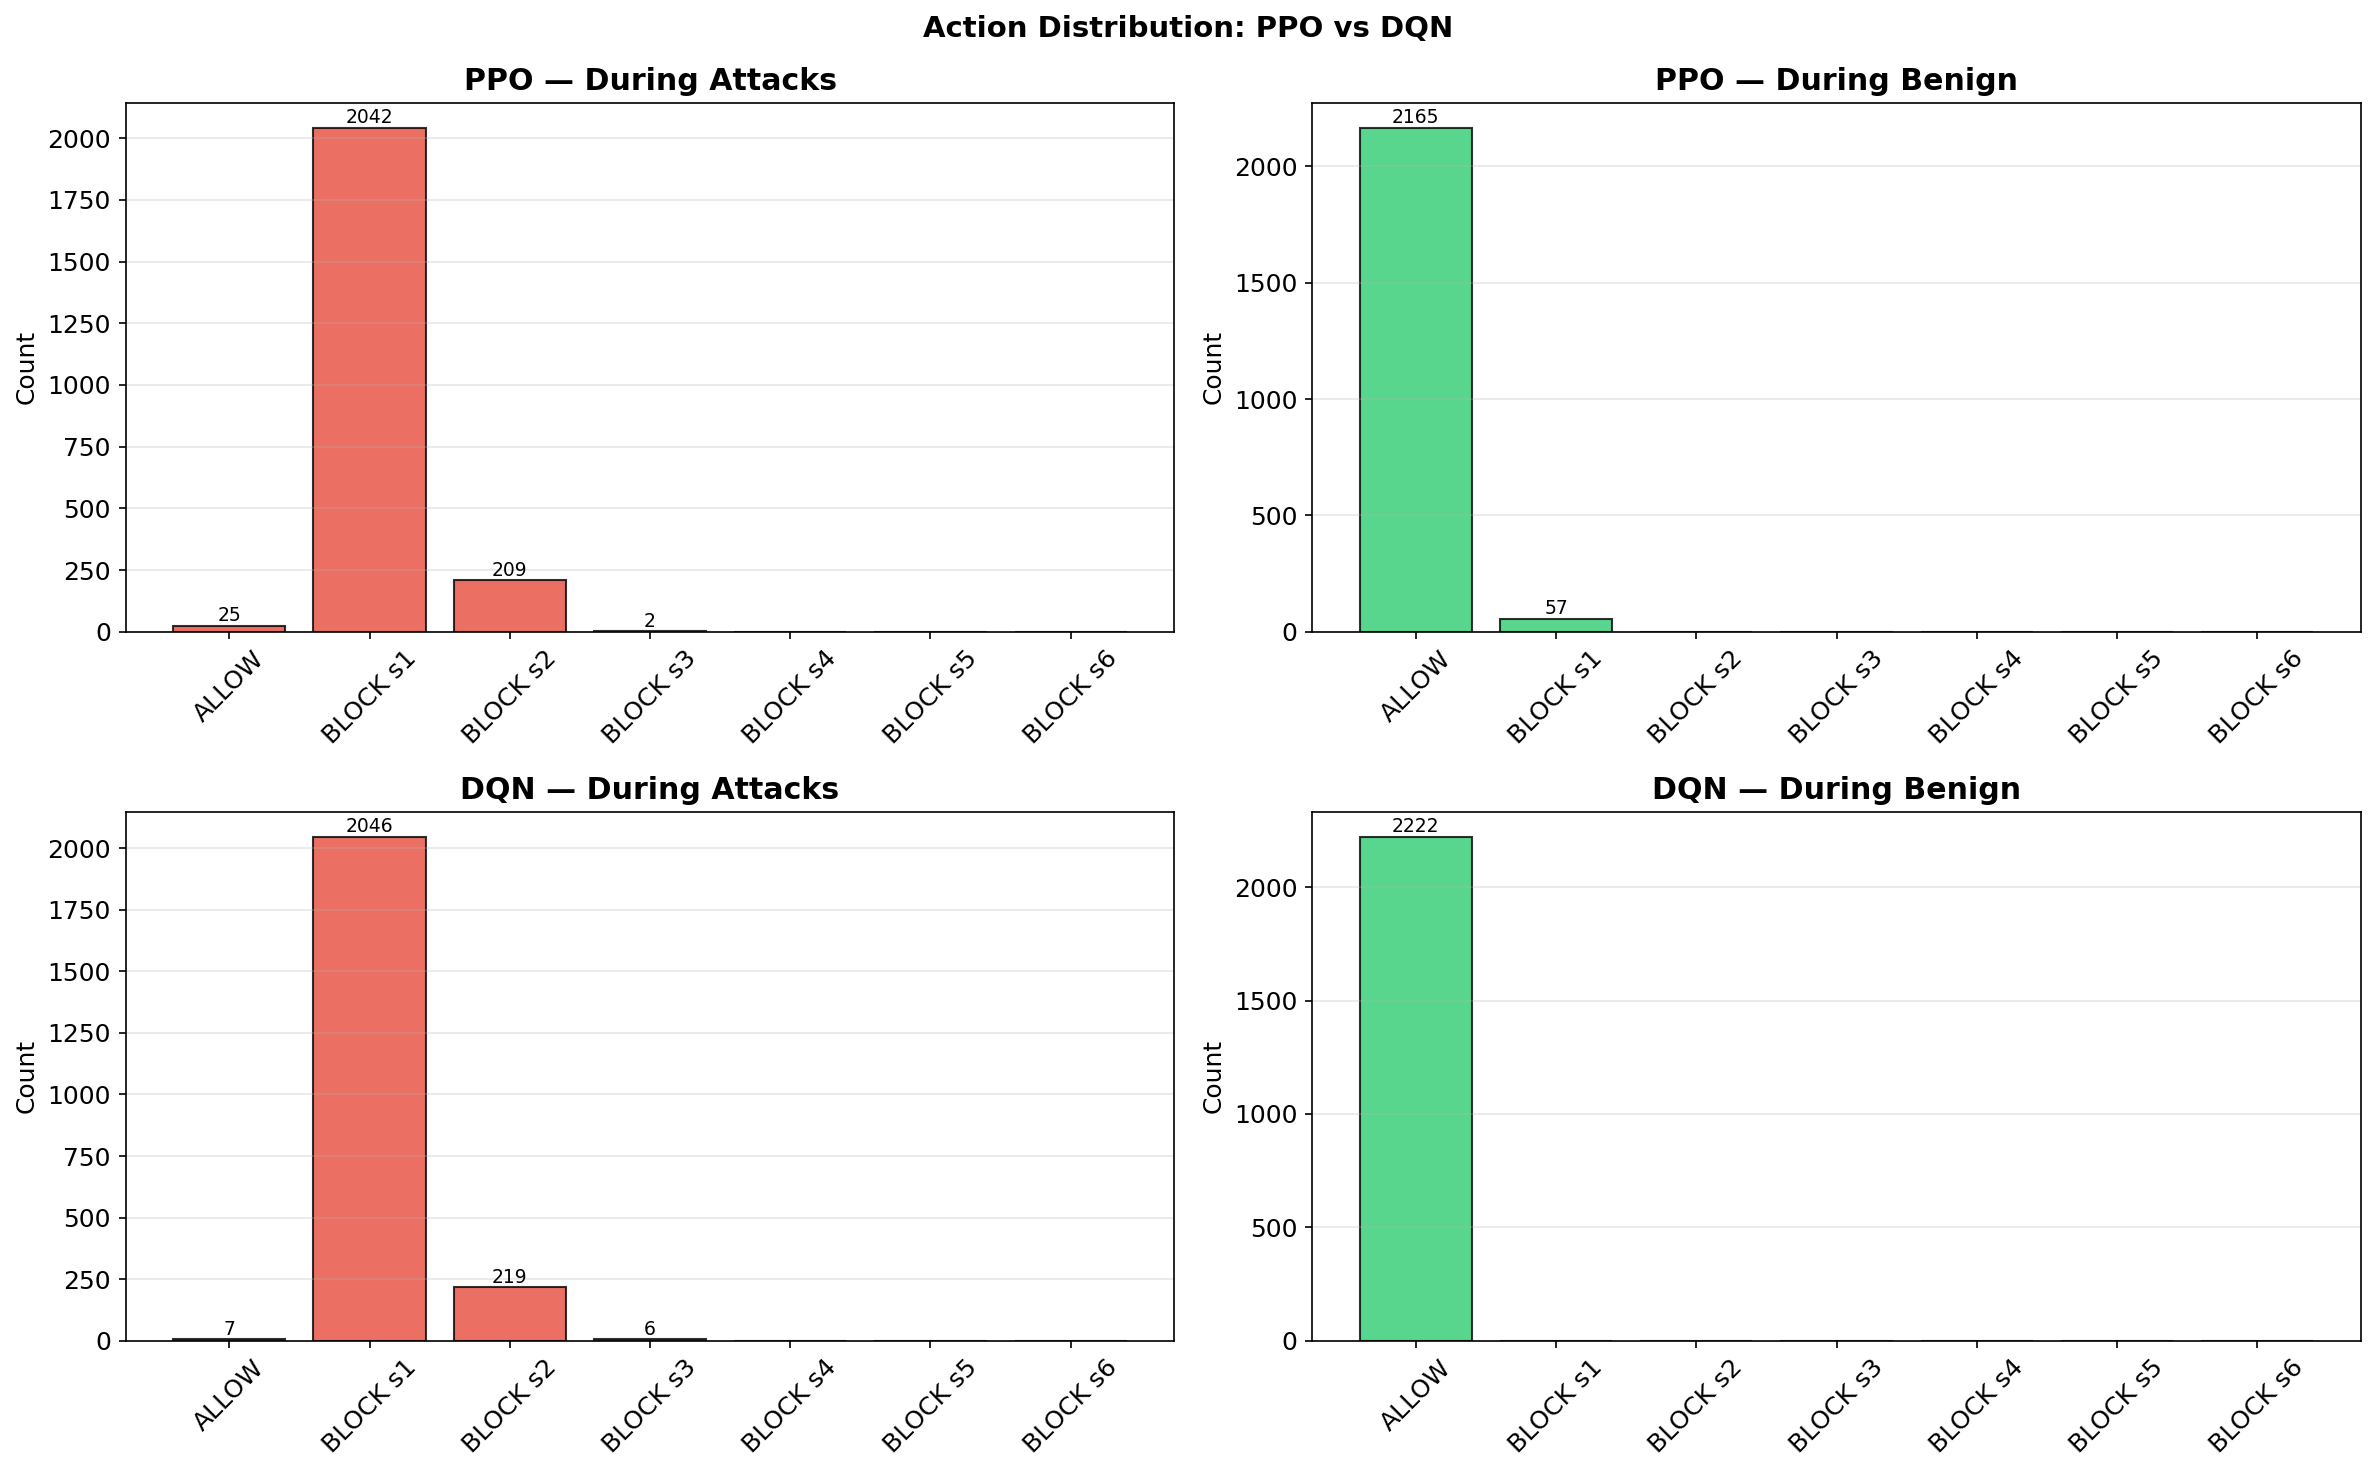

In [15]:
# ── Plot 4: Action distribution (Attack vs Benign) ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, (lbl, act, model_name) in enumerate([
    (ppo_lbl, ppo_act, "PPO"), (dqn_lbl, dqn_act, "DQN")
]):
    for col, (mask, title, color) in enumerate([
        (lbl == 1, "During Attacks",  "#e74c3c"),
        (lbl == 0, "During Benign",   "#2ecc71"),
    ]):
        ax = axes[row][col]
        acts = act[mask]
        counts = [np.sum(acts == a) for a in range(TOP_K+1)]
        bars = ax.bar(action_labels, counts, color=color, alpha=0.8, edgecolor="black")
        ax.set_title(f"{model_name} — {title}", fontweight="bold")
        ax.set_ylabel("Count"); ax.grid(True, alpha=0.3, axis='y')
        for bar, c in zip(bars, counts):
            if c > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                        str(c), ha='center', va='bottom', fontsize=9)
        ax.tick_params(axis='x', rotation=45)
plt.suptitle("Action Distribution: PPO vs DQN", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "4_action_distribution")
plt.show()

  ✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots/5_detection_speed.png


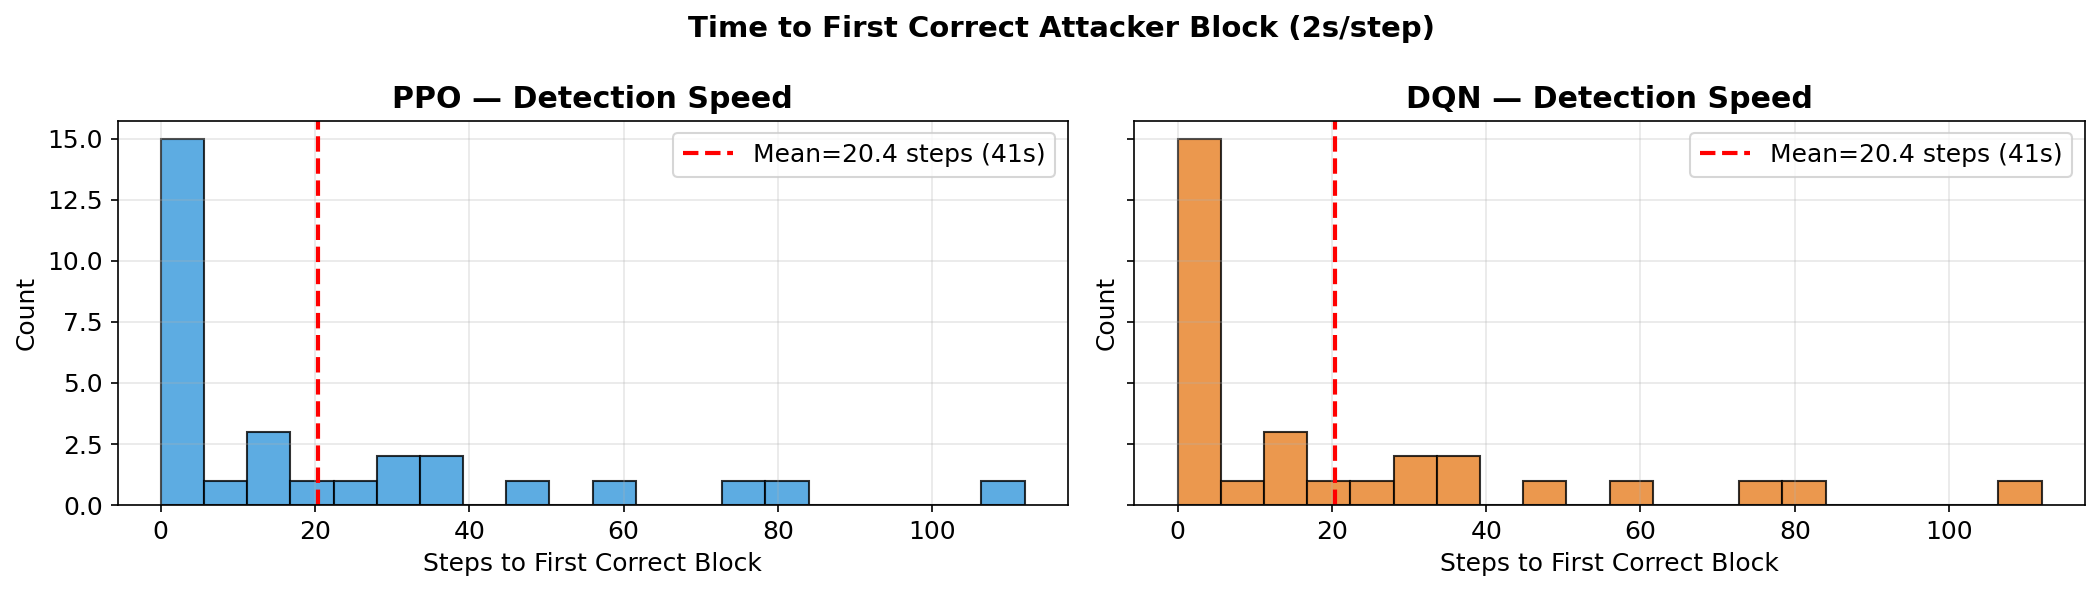

In [16]:
# ── Plot 5: Detection speed histogram ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, steps, name, color in [
    (axes[0], ppo_fs, "PPO", "#3498db"),
    (axes[1], dqn_fs, "DQN", "#e67e22"),
]:
    if len(steps) > 0:
        mean_s = np.mean(steps); mean_sec = mean_s * 2
        ax.hist(steps, bins=20, color=color, edgecolor="black", alpha=0.8)
        ax.axvline(mean_s, color="red", ls="--", lw=2,
                   label=f"Mean={mean_s:.1f} steps ({mean_sec:.0f}s)")
        ax.set_xlabel("Steps to First Correct Block")
        ax.set_ylabel("Count")
        ax.set_title(f"{name} — Detection Speed", fontweight="bold")
        ax.legend(); ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
plt.suptitle("Time to First Correct Attacker Block (2s/step)", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "5_detection_speed")
plt.show()

  ✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots/6_radar_comparison.png


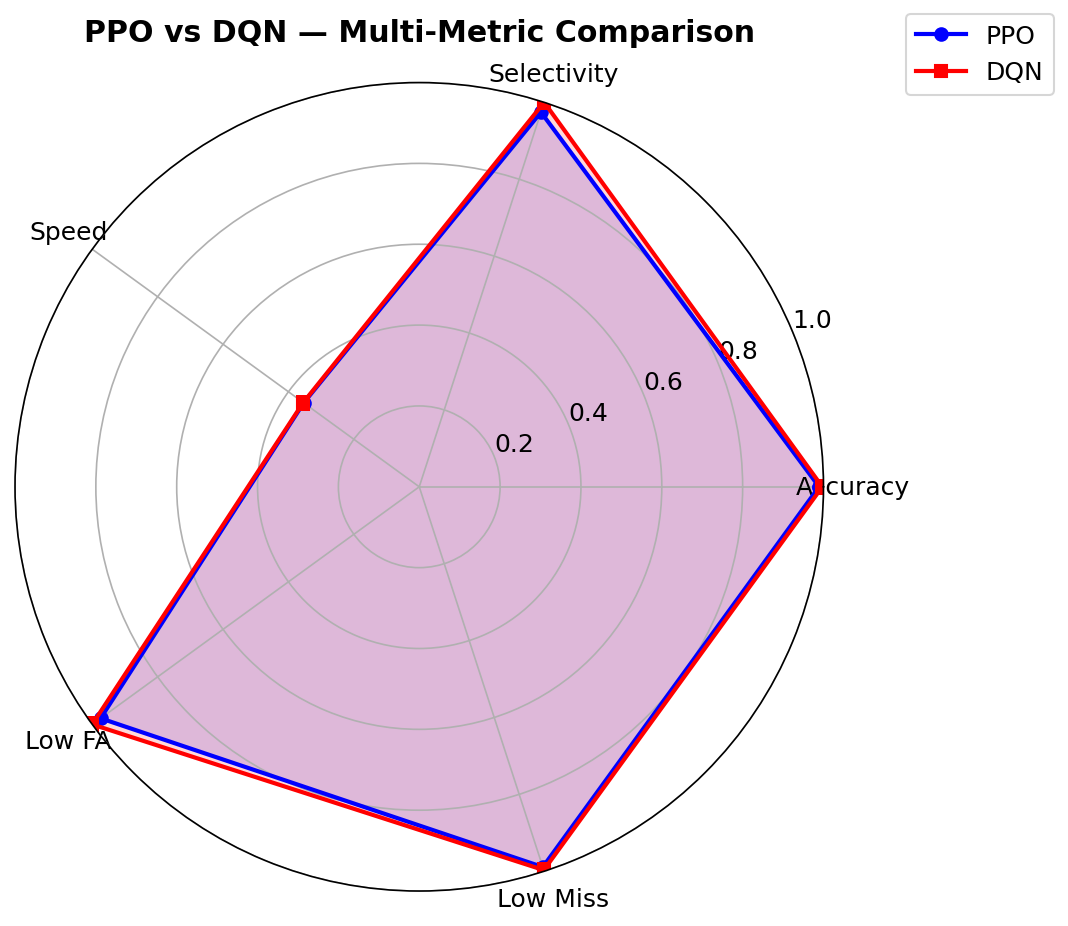

In [17]:
# ── Plot 6: Radar chart — multi-metric comparison ──
from matplotlib.patches import FancyArrowPatch
categories = ["Accuracy", "Selectivity", "Speed", "Low FA", "Low Miss"]
ppo_vals = [ppo_res["accuracy"], ppo_res["selectivity"], ppo_res["speed_norm"],
            1 - ppo_res["false_alarms"]/max(1,sum(ppo_lbl==0)),
            1 - ppo_res["missed"]/max(1,sum(ppo_lbl==1))]
dqn_vals = [dqn_res["accuracy"], dqn_res["selectivity"], dqn_res["speed_norm"],
            1 - dqn_res["false_alarms"]/max(1,sum(dqn_lbl==0)),
            1 - dqn_res["missed"]/max(1,sum(dqn_lbl==1))]

N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
ppo_vals_plot = ppo_vals + [ppo_vals[0]]
dqn_vals_plot = dqn_vals + [dqn_vals[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, ppo_vals_plot, "b-o", linewidth=2, label="PPO")
ax.fill(angles, ppo_vals_plot, alpha=0.15, color="blue")
ax.plot(angles, dqn_vals_plot, "r-s", linewidth=2, label="DQN")
ax.fill(angles, dqn_vals_plot, alpha=0.15, color="red")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title("PPO vs DQN — Multi-Metric Comparison", fontweight="bold", pad=20)
save_fig(fig, "6_radar_comparison")
plt.show()

  ✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots/7_performance_summary.png


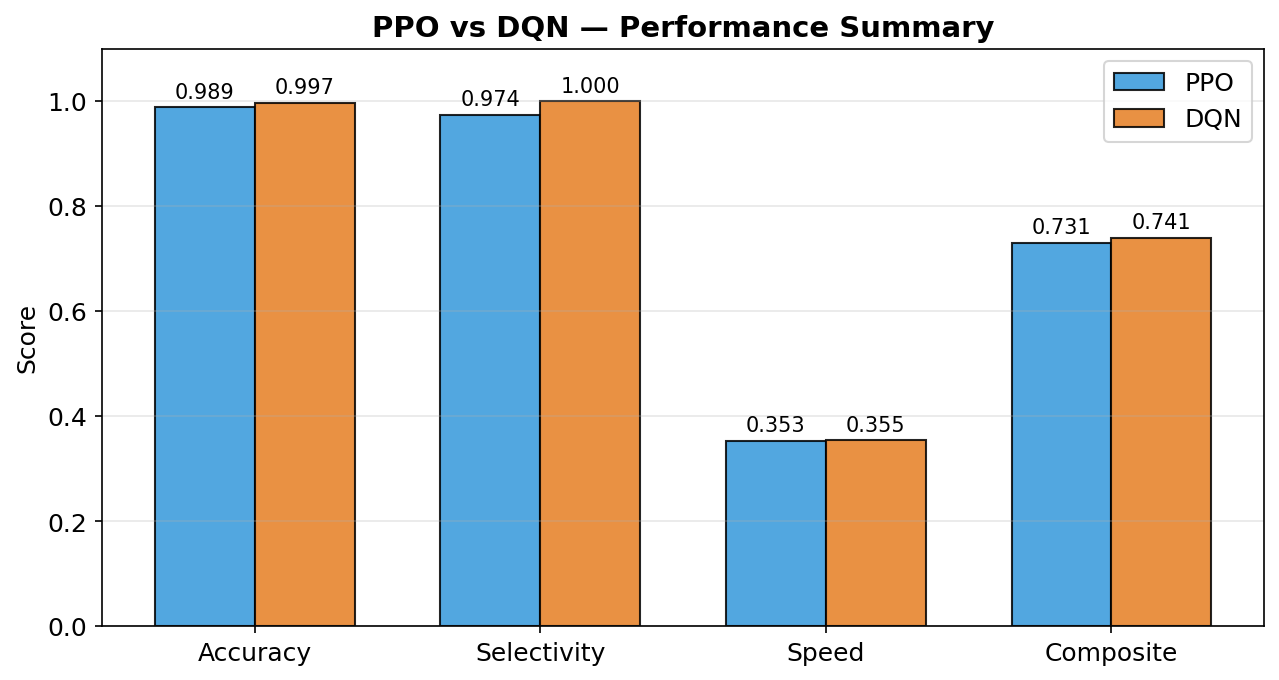

In [18]:
# ── Plot 7: Composite score comparison bar ──
metrics = ["Accuracy","Selectivity","Speed","Composite"]
ppo_bars = [ppo_res["accuracy"], ppo_res["selectivity"], ppo_res["speed_norm"], ppo_res["composite"]]
dqn_bars = [dqn_res["accuracy"], dqn_res["selectivity"], dqn_res["speed_norm"], dqn_res["composite"]]

x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, ppo_bars, w, label="PPO", color="#3498db", edgecolor="black", alpha=0.85)
b2 = ax.bar(x + w/2, dqn_bars, w, label="DQN", color="#e67e22", edgecolor="black", alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("PPO vs DQN — Performance Summary", fontweight="bold", fontsize=14)
ax.legend(fontsize=12); ax.grid(True, alpha=0.3, axis='y')
save_fig(fig, "7_performance_summary")
plt.show()

## Section 11 — Final Metrics Table & Save Artifacts

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

summary_rows = []
for name, res, lbl, act in [("PPO", ppo_res, ppo_lbl, ppo_act),
                              ("DQN", dqn_res, dqn_lbl, dqn_act)]:
    pred_bin = (act > 0).astype(int)
    summary_rows.append({
        "Algorithm":              name,
        "Composite Score":        f"{res['composite']:.4f}",
        "Attacker ID Accuracy":   f"{res['accuracy']:.4f}",
        "Selectivity":            f"{res['selectivity']:.4f}",
        "Detection F1":           f"{f1_score(lbl, pred_bin):.4f}",
        "Detection Precision":    f"{precision_score(lbl, pred_bin, zero_division=0):.4f}",
        "Detection Recall":       f"{recall_score(lbl, pred_bin, zero_division=0):.4f}",
        "Mean Detection Time (s)":f"{res['mean_detection_sec']:.1f}",
        "False Alarm Rate":       f"{res['false_alarms']/max(1,sum(lbl==0)):.4f}",
        "Mean Episode Reward":    f"{res['mean_reward']:.2f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Algorithm")
print(summary_df.T.to_string())
summary_df.to_csv(OUT_DIR / "final_comparison.csv")
print(f"\n✅ Saved: {OUT_DIR}/final_comparison.csv")
print(f"   All plots in: {PLOT_DIR}")

recipe = {
    "ppo_model":  str(OUT_DIR / "ppo_model.zip"),
    "dqn_model":  str(OUT_DIR / "dqn_model.zip"),
    "obs_scaler": str(OUT_DIR / "obs_scaler.pkl"),
    "obs_dim": OBS_DIM,
    "top_k": TOP_K,
    "action_meanings": {"0":"ALLOW", **{str(k):f"BLOCK_src{k}" for k in range(1,TOP_K+1)}},
    "ppo_best_params": ppo_best.params,
    "dqn_best_params": dqn_best.params,
    "ppo_eval": {k:v for k,v in ppo_res.items() if k != "ep_data"},
    "dqn_eval": {k:v for k,v in dqn_res.items() if k != "ep_data"},
    "gt_method": gt_method,
}
with open(OUT_DIR / "deployment_recipe.json", "w") as f:
    json.dump(recipe, f, indent=2, default=str)
print(f"   Deployment recipe: {OUT_DIR}/deployment_recipe.json")

print(f"\n{'='*55}")
winner = "PPO" if ppo_res['composite'] > dqn_res['composite'] else "DQN"
print(f"🏆  WINNER: {winner}")
print(f"  PPO composite: {ppo_res['composite']:.4f}  DQN: {dqn_res['composite']:.4f}")
print(f"  PPO det time:  {ppo_res['mean_detection_sec']:.1f}s  DQN: {dqn_res['mean_detection_sec']:.1f}s")
print(f"{'='*55}")

Algorithm                   PPO     DQN
Composite Score          0.7311  0.7408
Attacker ID Accuracy     0.9890  0.9969
Selectivity              0.9743  1.0000
Detection F1             0.9821  0.9985
Detection Precision      0.9753  1.0000
Detection Recall         0.9890  0.9969
Mean Detection Time (s)   194.0   193.6
False Alarm Rate         0.0257  0.0000
Mean Episode Reward      200.55  446.55

✅ Saved: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/final_comparison.csv
   All plots in: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/plots
   Deployment recipe: /home/shokran/PycharmProjects/JupyterProject/Models/newTrail/outputs_ppo_dqn_compare/deployment_recipe.json

🏆  WINNER: DQN
  PPO composite: 0.7311  DQN: 0.7408
  PPO det time:  194.0s  DQN: 193.6s
